# Week 1: System exploration (Group)

In the first stage, your aim is to **understand the behaviour of a system**.

You should focus on questions like:

- How do the observed signals change over time?
- How do different input patterns affect the observations?
- Are some signals more informative than others?
- What is easy to observe, and what seems hidden?

At this stage, the priority is **exploration and intuition-building**, not solving the whole project.

## Group tasks for Week 1

As a group, extend the basic experiment and **build a shared code workflow.**

Your group should aim to produce:

- a clean way to explore dataset, either from simulation or experiment,
- standard plotting functions,
- a simulation platform for studying and comparing effects of different input patterns and system dynamics (transition matrices), for example:
  - random inputs,
  - pulses,
  - oscillatory inputs,
  - activating only one input channel at a time,
  - activating different channels with different amplitudes,
  - exploring the relationship between input structure and system dynamics (such as coupling between inputs and transition matrices);
- brief documentation so that all group members can build on the same starting point.

All of the above tasks should be completed by Friday 22 May, before the scheduled check-in session.

## Week 1 deliverable

**Deliverable:** Group simulation code + brief documentation  
**Marks:** 10 group marks  
**Due:** Friday 22 May, 11am–1pm (**compulsory session**)

At the check-in session, the demonstrator will review the code and ask each member of the group questions about it. Every member of the group is therefore expected to have contributed to the code and to take full responsibility for understanding it.


## Example dataset


In [1]:
# loading dataset
import numpy as np

data = np.load("ExampleDataset.npy")
print(
    "Dataset loaded successfully. Shape:", data.shape
)  # (Trials, Timepoints, Neurons)

Dataset loaded successfully. Shape: (5, 60, 16)


## Design an illustrator

A class that can generate primary statistics, analyses, and visualization of any dataset. Design your illustrator in **Illustrator.py**.

To test your documentation, the demonstrator will use your illustrator here, but will never see your code (in this section).

Please make your annotations clear and comprehensive!


Dataset summary
  Shape      : (5, 60, 16)  (n_trials=5, n_timesteps=60, n_neurons=16)

  Neuron             Mean      SEM      Min      Max
  ------------------------------------------------
  Neuron 0          3.292    0.000   -1.793    9.791
  Neuron 1          3.233    0.000   -0.883    9.424
  Neuron 2          3.404    0.000   -2.127    9.832
  Neuron 3          2.293    0.000   -1.580    6.911
  Neuron 4          3.500    0.000   -3.000    9.746
  Neuron 5          3.345    0.000   -0.454   10.161
  Neuron 6          3.412    0.000   -1.363   11.194
  Neuron 7          2.246    0.000   -2.275    6.743
  Neuron 8          3.329    0.000   -1.569   10.299
  Neuron 9          3.580    0.000   -1.381   10.671
  Neuron 10         3.209    0.000   -1.002   10.733
  Neuron 11         3.203    0.000   -2.088   10.256
  Neuron 12         3.430    0.000   -1.448    9.625
  Neuron 13         3.601    0.000   -1.351   10.517
  Neuron 14         3.731    0.000   -1.452   10.246
  Neuron 15  

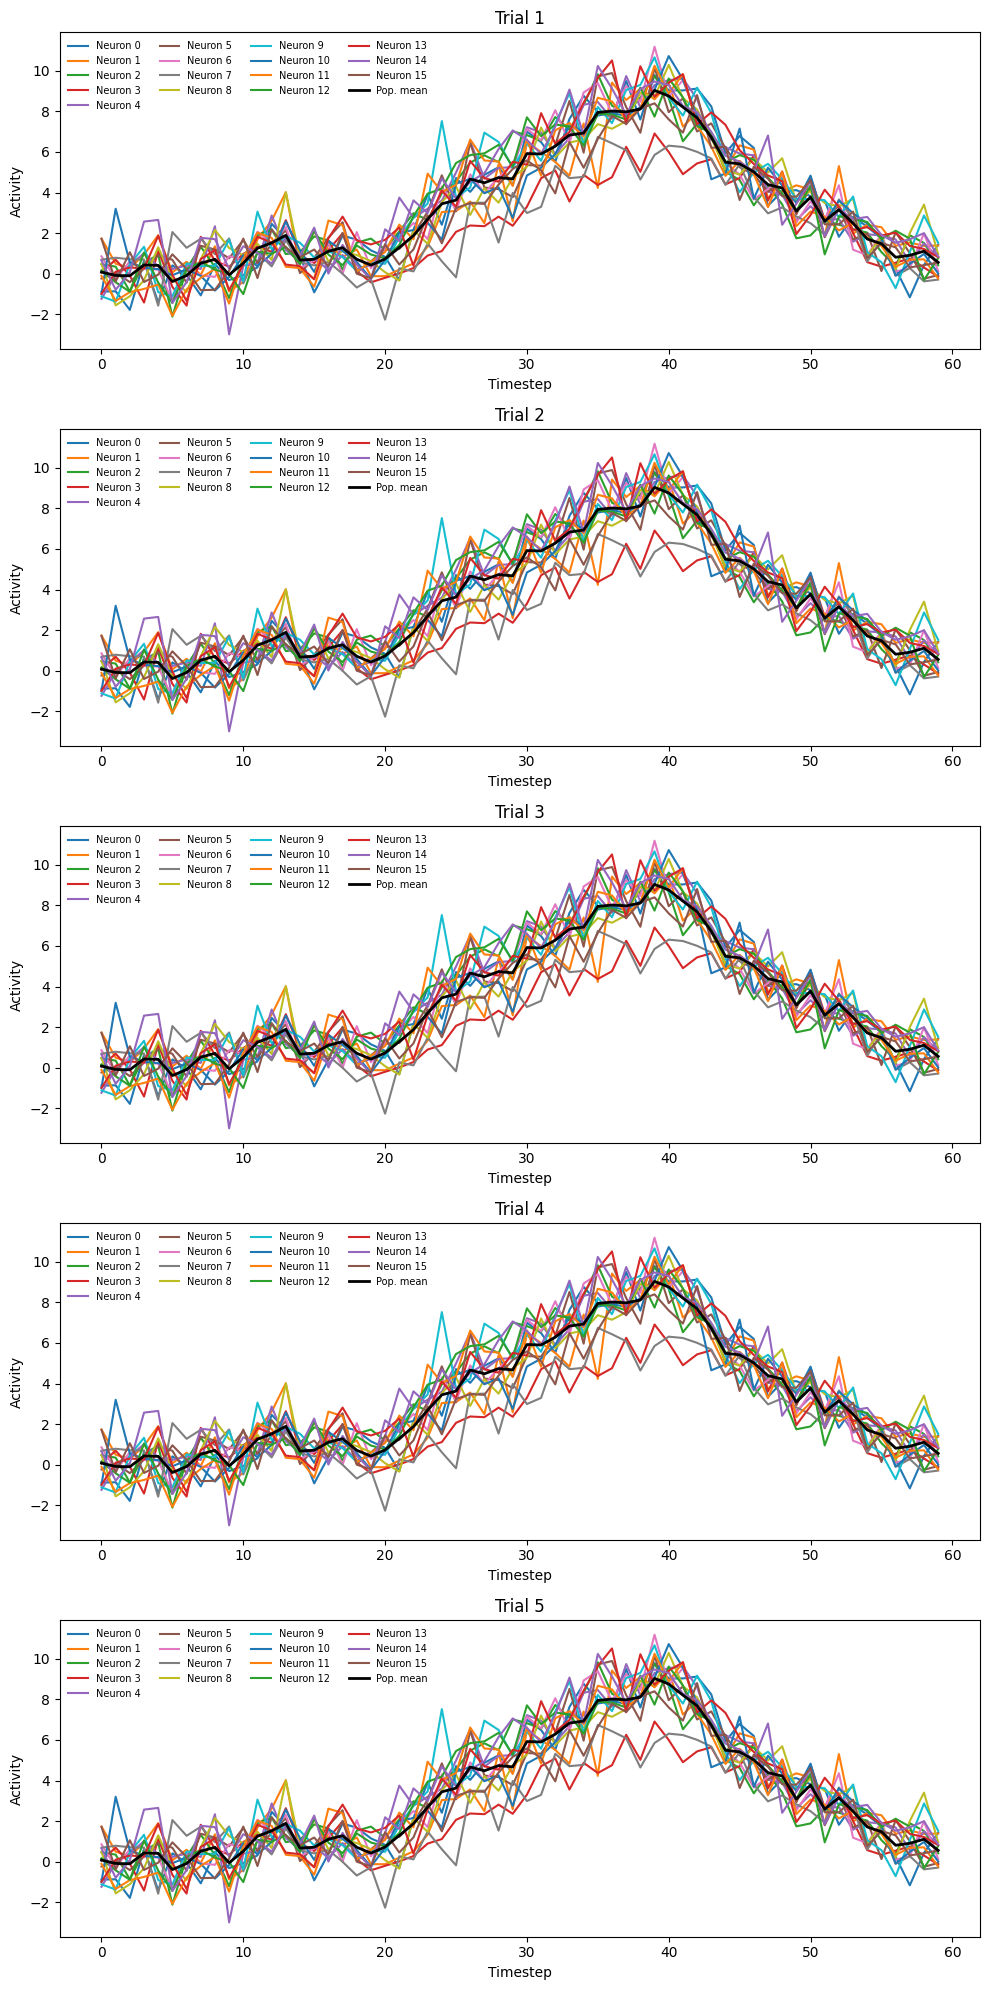

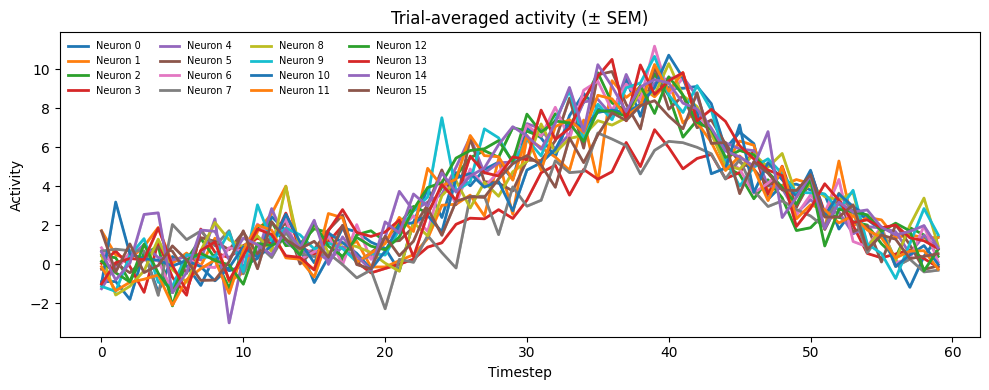

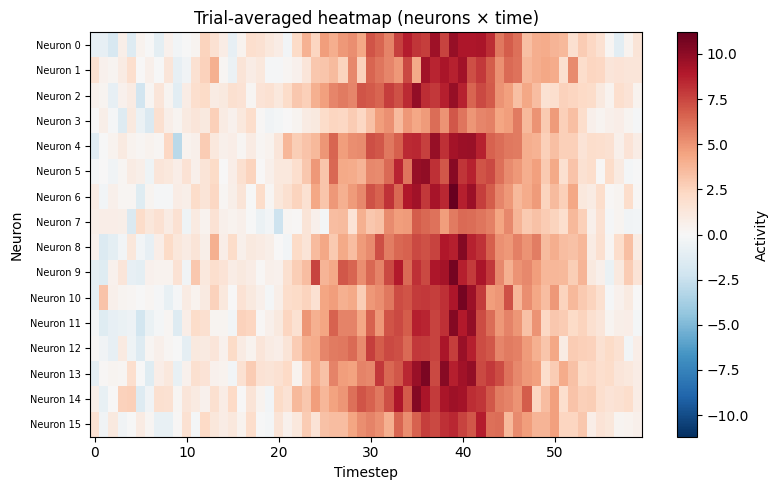

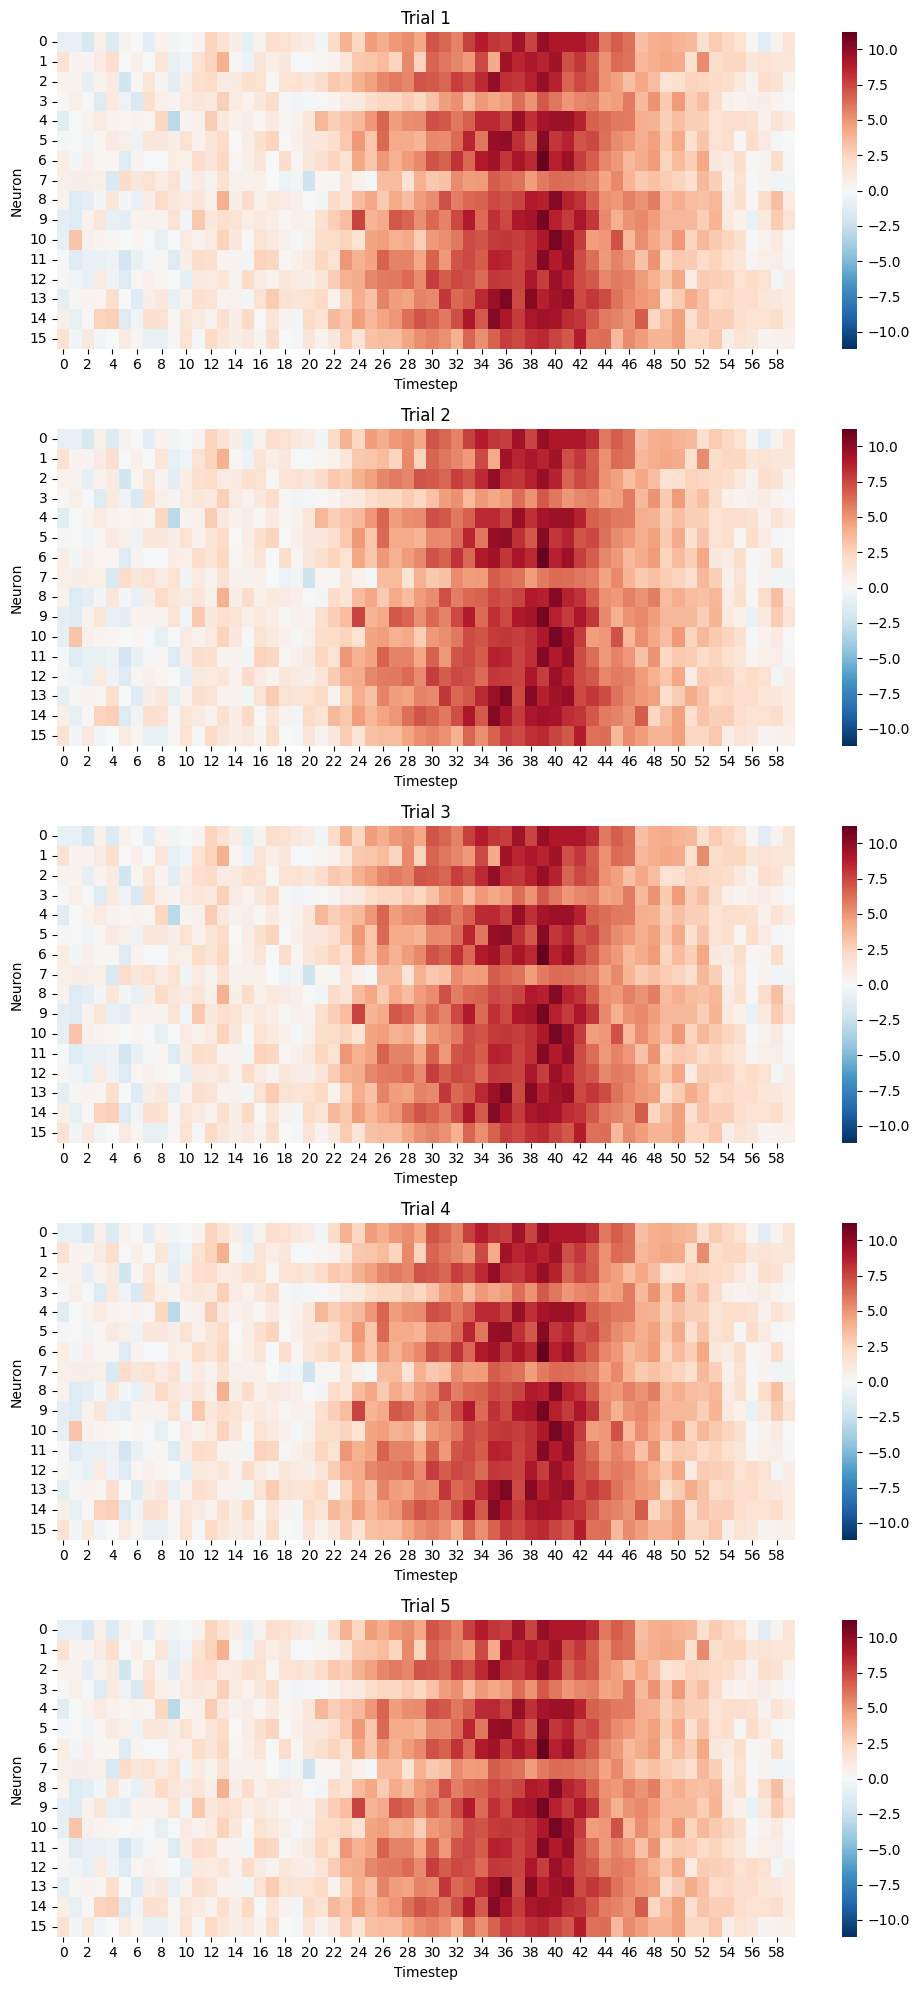

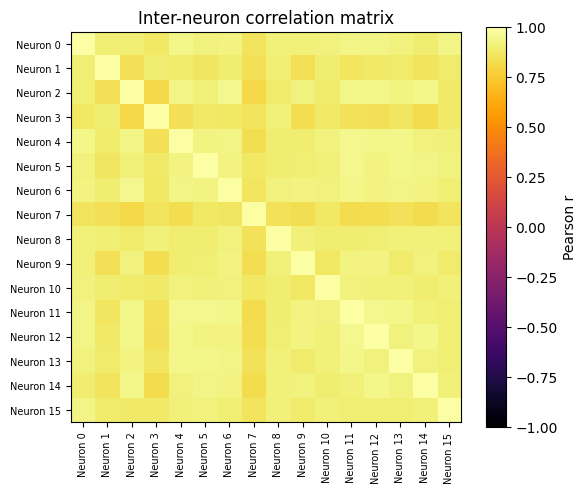

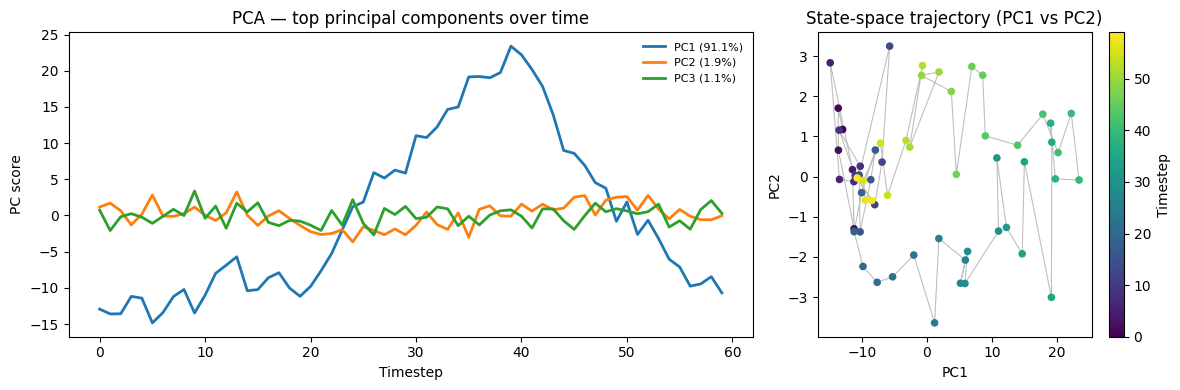

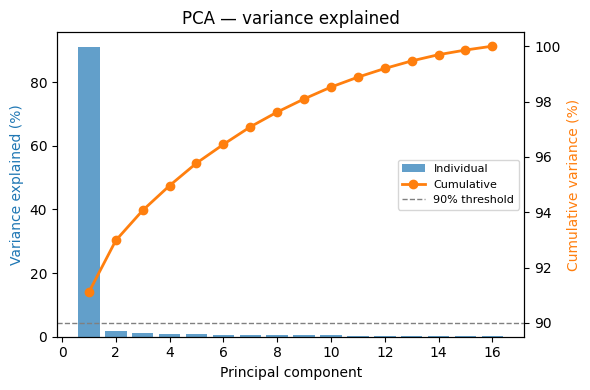

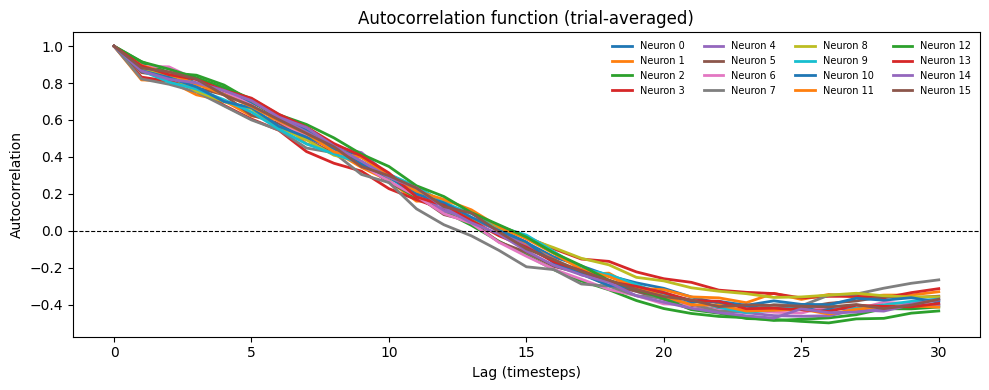

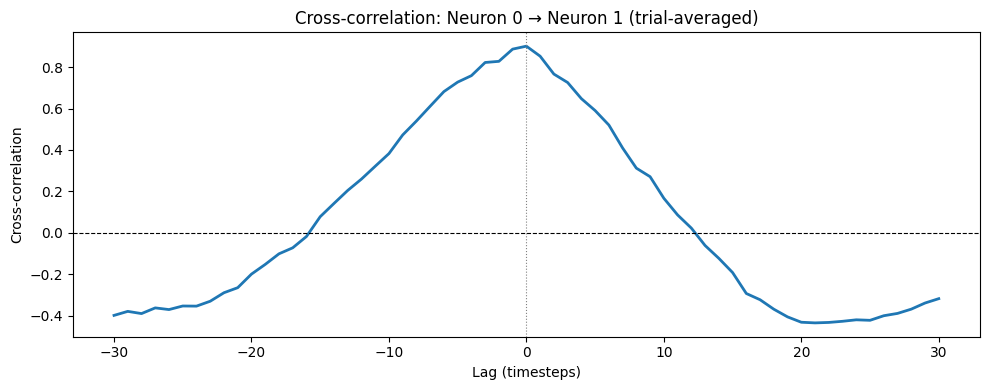

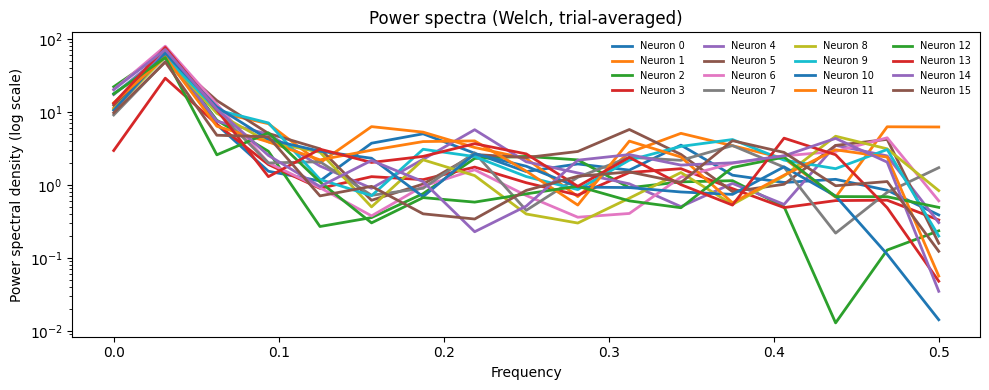

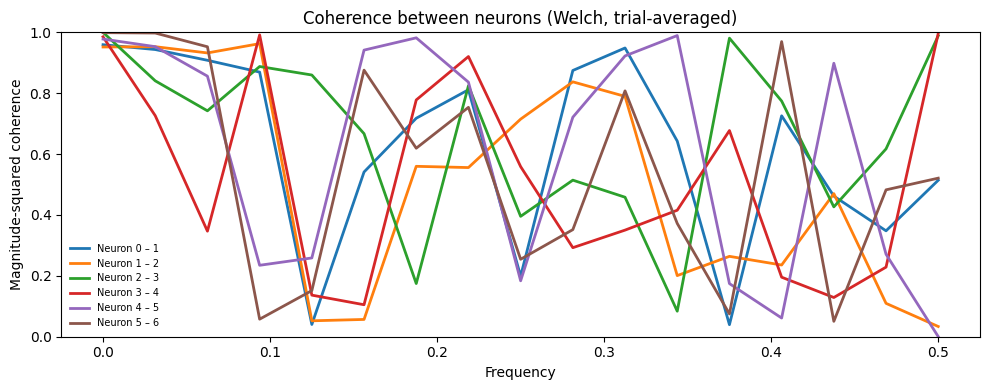

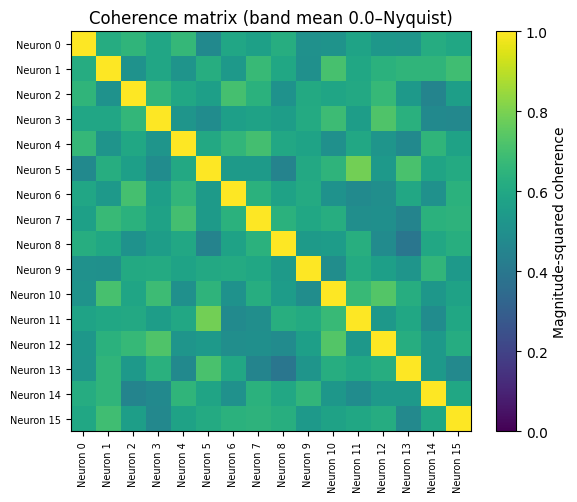

In [2]:
from l4b.illustrator import Illustrator

illustrator = Illustrator(data)
_ = illustrator.plot_all()

## Design a simulator

In GG4, we use a simple linear model:

$$
x_{t+1} = Ax_t + Bu_t + w_t, w_t \sim \mathcal{N}(0, Q)
$$

$$
y_t = Cx_t + o_t, o_t \sim \mathcal{N}(0, R)
$$

Your simulator should be able to simulate observation of any length given different parameters.

Design your simulator in **Simulator.py**.

To test your documentation, the demonstrator will use your simulator here, but will never see your code (in this section).
Please make your annotations clear and comprehensive!

Combining the illustrator and simulator, what's your findings? Illustrate them.
This forms your answer to the question: "effects of different input patterns and system dynamics"


States:       (10, 100, 2)  # (trials, timesteps, state_dim)
Observations: (10, 100, 2)  # (trials, timesteps, obs_dim)


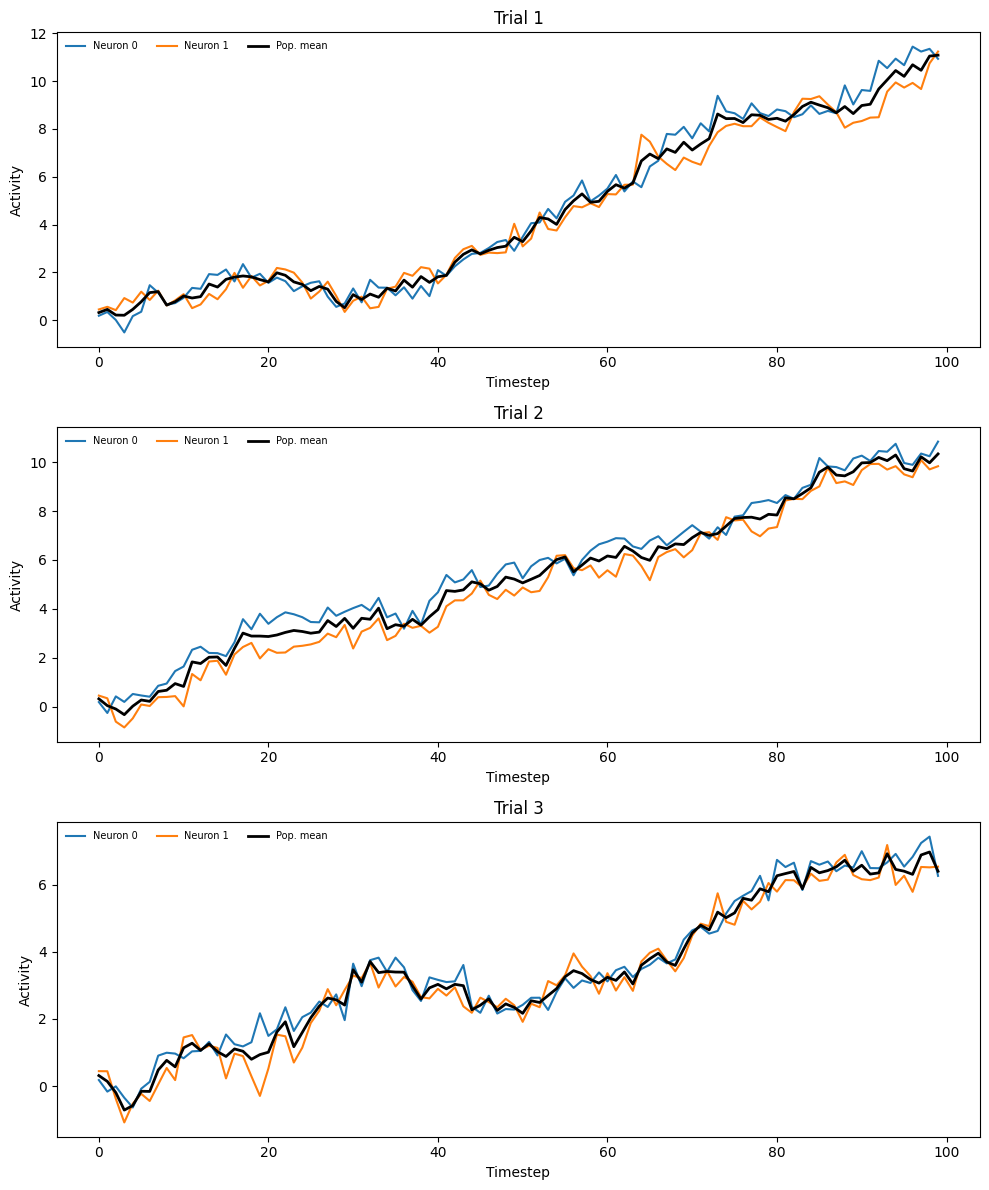

In [3]:
from l4b.simulation import Simulator
from l4b import InputSignal
import numpy as np

# Corrected minimal example: 2 latent states, 1 input, 2 observed neurons
T = 100
model = {
    "state_dim": 2,
    "input_dim": 1,
    "obs_dim": 2,
    "A": np.array([[0.9, 0.1], [0.2, 0.8]]),
    "B": np.array([[0.5], [0.2]]),
    "C": np.eye(2),  # observe both latent states
    "Q": np.eye(2) * 0.1,  # isotropic process noise
    "R": np.eye(2) * 0.05,  # isotropic observation noise
}

sim = Simulator(model)
# Constant input of amplitude 0.3 across all T timesteps, modelled as a
# pulse spanning the whole horizon.
u = InputSignal.pulse(T, m=1, onset=0, duration=T, amplitude=0.3)
states, observations = sim.run(
    initial_state=np.zeros(2),  # shape (state_dim,)
    control_inputs=np.asarray(u),
    time_steps=T,
    trials=10,
)
print(f"States:       {states.shape}  # (trials, timesteps, state_dim)")
print(f"Observations: {observations.shape}  # (trials, timesteps, obs_dim)")

from l4b.illustrator import Illustrator

fig = Illustrator(observations).plot_trials(trials=[0, 1, 2])

## Input pattern comparison

We hold the model $(A, B, C, Q, R)$ fixed and vary only the input signal $u_t$ to isolate how each driving pattern shapes the observations.

Patterns studied:

- **Zero input**: baseline free decay; any activity reflects initial conditions and noise only.
- **Constant step**: sustained driving; reveals the steady-state gain $B(I-A)^{-1}$.
- **Pulse**: brief activation; traces the system's _impulse response_, shaped entirely by $A$.
- **Oscillatory (slow / fast)**: reveals frequency-selective filtering: $A$ attenuates inputs faster than its dominant time constant.


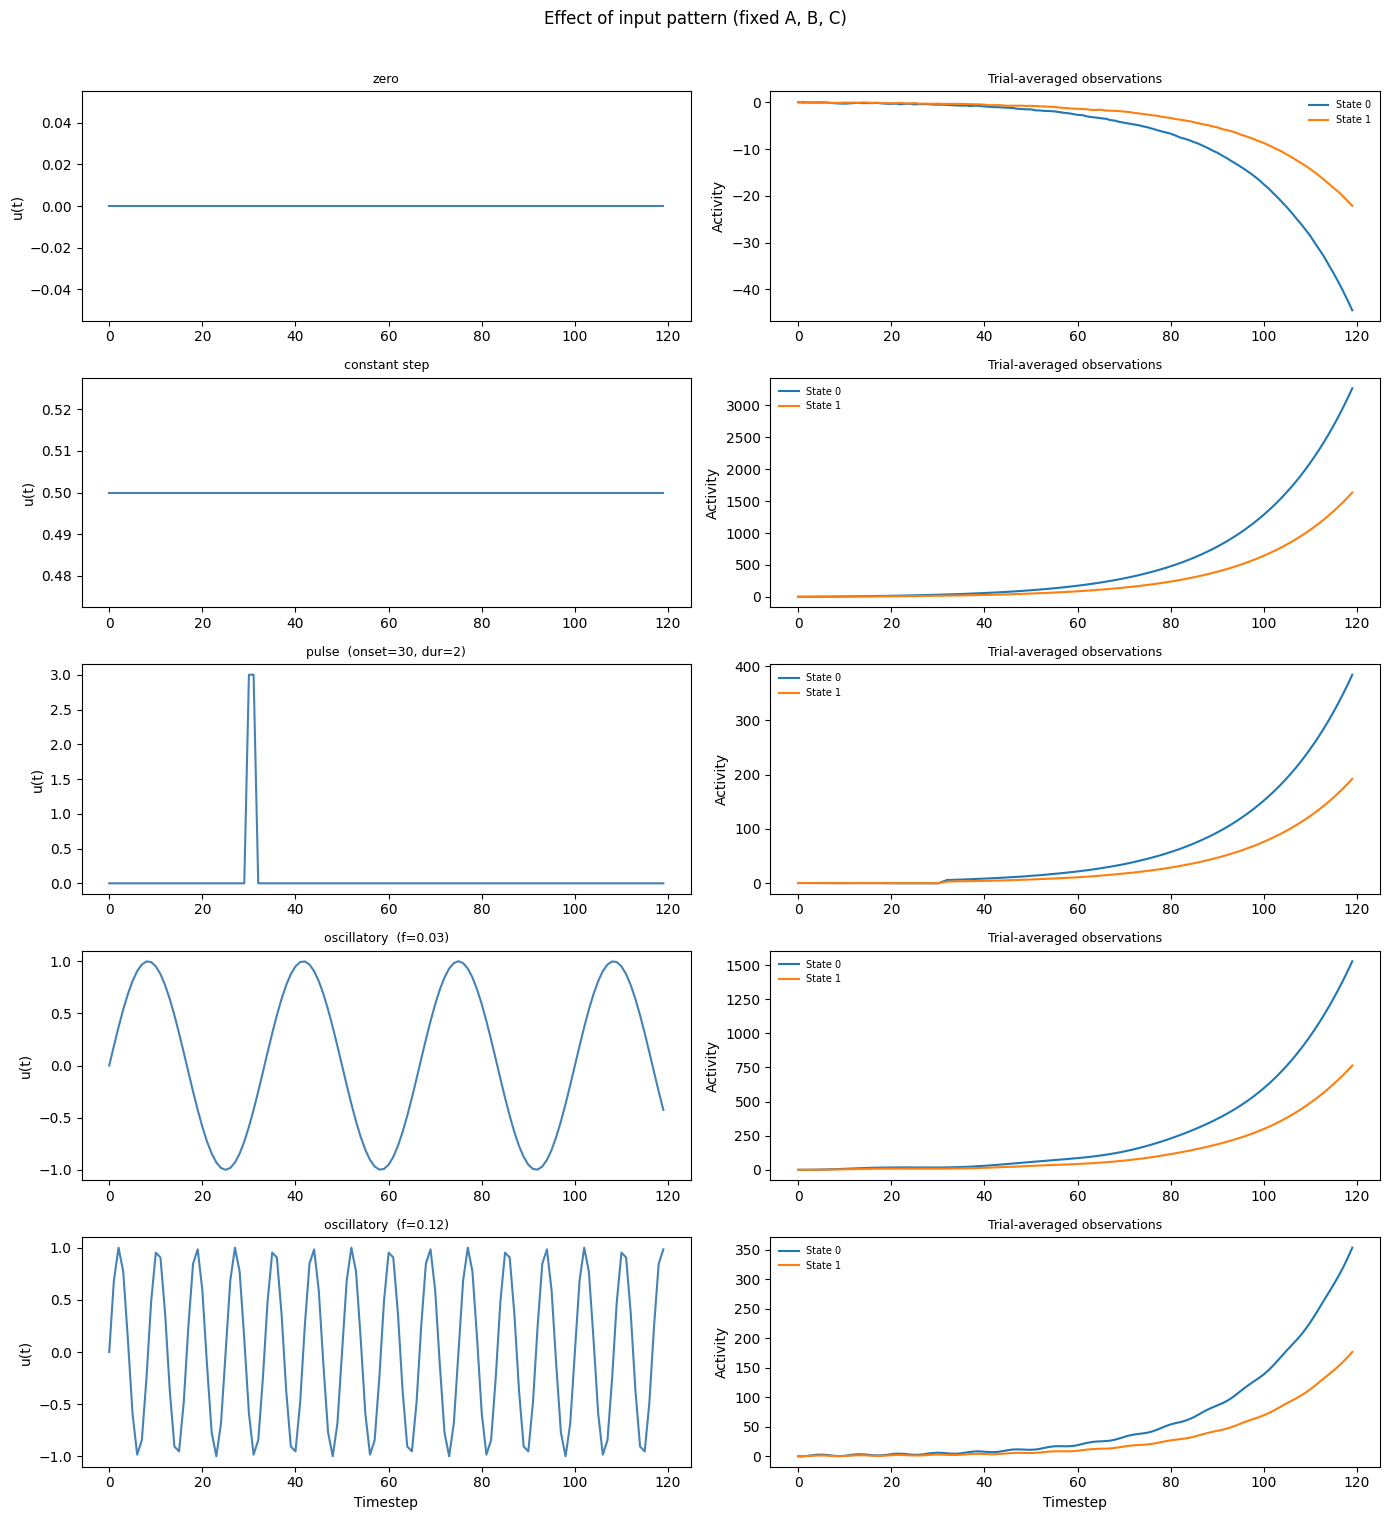

In [4]:
from l4b import InputSignal
from l4b.simulation import Simulator
import matplotlib.pyplot as plt
import numpy as np

T, n_trials = 120, 30
state_dim, input_dim, obs_dim = 2, 1, 2

ref_model = {
    "state_dim": state_dim,
    "input_dim": input_dim,
    "obs_dim": obs_dim,
    "A": np.array([[0.9, 0.3], [0.1, 0.85]]),
    "B": np.array([[1.0], [0.5]]),
    "C": np.eye(obs_dim),
    "Q": np.eye(state_dim) * 0.05,
    "R": np.eye(obs_dim) * 0.02,
    "seed": 0,
}

# Each condition is constructed via InputSignal factory methods. A constant
# step is modelled as a pulse spanning the whole horizon.
conditions = {
    "zero": InputSignal.zero(T, input_dim),
    "constant step": InputSignal.pulse(
        T, input_dim, onset=0, duration=T, amplitude=0.5
    ),
    "pulse  (onset=30, dur=2)": InputSignal.pulse(
        T, input_dim, onset=30, duration=2, amplitude=3.0
    ),
    "oscillatory  (f=0.03)": InputSignal.oscillatory(T, input_dim, frequency=0.03),
    "oscillatory  (f=0.12)": InputSignal.oscillatory(T, input_dim, frequency=0.12),
}

fig, axes = plt.subplots(len(conditions), 2, figsize=(14, 3 * len(conditions)))

for row, (label, u) in enumerate(conditions.items()):
    _, obs = Simulator(ref_model).run(
        initial_state=np.zeros(state_dim),
        control_inputs=np.asarray(u),
        time_steps=T,
        trials=n_trials,
    )
    mean_obs = obs.mean(axis=0)

    axes[row, 0].plot(np.asarray(u)[:, 0], color="steelblue")
    axes[row, 0].set_title(label, fontsize=9)
    axes[row, 0].set_ylabel("u(t)")

    for k in range(obs_dim):
        axes[row, 1].plot(mean_obs[:, k], label=f"State {k}")
    axes[row, 1].set_title("Trial-averaged observations", fontsize=9)
    axes[row, 1].set_ylabel("Activity")
    axes[row, 1].legend(fontsize=7, frameon=False)

for ax in axes[-1]:
    ax.set_xlabel("Timestep")

fig.suptitle("Effect of input pattern (fixed A, B, C)", y=1.01)
fig.tight_layout()
plt.show()

## Multi-channel input comparison

With multiple input channels ($m > 1$), each column of $B$ determines how a particular channel injects energy into the state space. We compare:

- **All channels together**: full-rank stimulation; the response is the superposition of each column's impulse response.
- **Single channel at a time**: isolates the direction each input drives in state space; useful for identifying which states are reachable from which channels.
- **Different amplitudes**: probes how asymmetric driving shifts the steady-state or peak response.


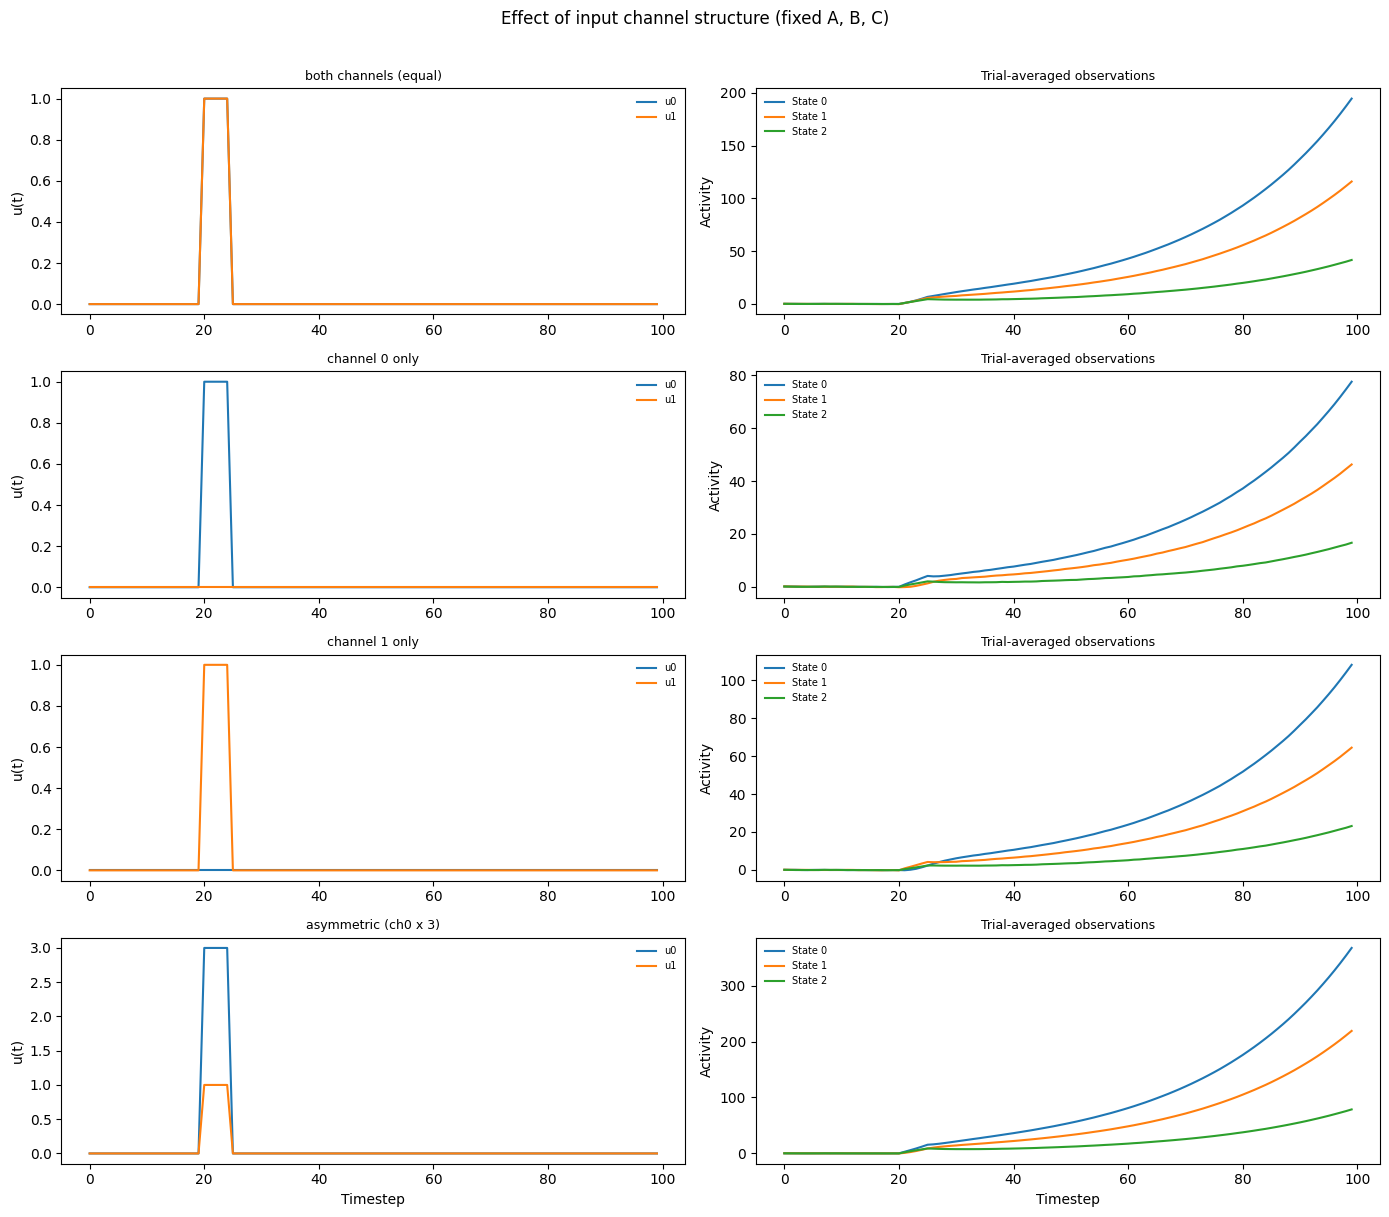

In [5]:
from l4b.inputs import InputBuilder
from l4b.simulation import Simulator
import matplotlib.pyplot as plt
import numpy as np

T = 100
state_dim, input_dim, obs_dim = 3, 2, 3

multi_model = {
    "state_dim": state_dim,
    "input_dim": input_dim,
    "obs_dim": obs_dim,
    "A": np.array([[0.85, 0.30, 0.05], [0.10, 0.80, 0.20], [0.00, 0.05, 0.90]]),
    "B": np.array(
        [
            [1.0, 0.0],  # channel 0 to state 0
            [0.0, 1.0],  # channel 1 to state 1
            [0.5, 0.5],
        ]
    ),  # both channels weakly to state 2
    "C": np.eye(obs_dim),
    "Q": np.eye(state_dim) * 0.02,
    "R": np.eye(obs_dim) * 0.01,
    "seed": 1,
}

# Use InputBuilder to compose per-channel pulses in a single fluent chain
# rather than np.hstack-ing separate arrays together.
onset = 20
conditions_mc = {
    "both channels (equal)": (
        InputBuilder(T=T, m=input_dim)
        .pulse(onset=onset, duration=5, channels=[0], amplitude=1.0)
        .pulse(onset=onset, duration=5, channels=[1], amplitude=1.0)
        .build()
    ),
    "channel 0 only": (
        InputBuilder(T=T, m=input_dim)
        .pulse(onset=onset, duration=5, channels=[0], amplitude=1.0)
        .build()
    ),
    "channel 1 only": (
        InputBuilder(T=T, m=input_dim)
        .pulse(onset=onset, duration=5, channels=[1], amplitude=1.0)
        .build()
    ),
    "asymmetric (ch0 x 3)": (
        InputBuilder(T=T, m=input_dim)
        .pulse(onset=onset, duration=5, channels=[0], amplitude=3.0)
        .pulse(onset=onset, duration=5, channels=[1], amplitude=1.0)
        .build()
    ),
}

fig, axes = plt.subplots(len(conditions_mc), 2, figsize=(14, 3 * len(conditions_mc)))

for row, (label, u) in enumerate(conditions_mc.items()):
    u_arr = np.asarray(u)
    _, obs = Simulator(multi_model).run(np.zeros(state_dim), u_arr, T, trials=20)
    mean_obs = obs.mean(axis=0)

    for ch in range(input_dim):
        axes[row, 0].plot(u_arr[:, ch], label=f"u{ch}")
    axes[row, 0].set_title(label, fontsize=9)
    axes[row, 0].set_ylabel("u(t)")
    axes[row, 0].legend(fontsize=7, frameon=False)

    for k in range(obs_dim):
        axes[row, 1].plot(mean_obs[:, k], label=f"State {k}")
    axes[row, 1].set_title("Trial-averaged observations", fontsize=9)
    axes[row, 1].set_ylabel("Activity")
    axes[row, 1].legend(fontsize=7, frameon=False)

for ax in axes[-1]:
    ax.set_xlabel("Timestep")

fig.suptitle("Effect of input channel structure (fixed A, B, C)", y=1.01)
fig.tight_layout()
plt.show()

## Effect of transition matrix structure

With input pattern held fixed, we vary $A$ to see how eigenvalue placement and coupling structure shape the response:

- **Stable decaying**: all $|\lambda_i| < 1$; signals decay exponentially at a rate set by the spectral radius.
- **Near-marginal**: eigenvalues close to the unit circle; slow decay, long memory, large trial-to-trial variability.
- **Oscillatory (complex eigenvalues)**: persistent oscillations even under a single brief pulse; frequency set by $\arg(\lambda)$.
- **Coupled (off-diagonal $A$)**: cross-channel interactions; a pulse into one state dimension drives the others.


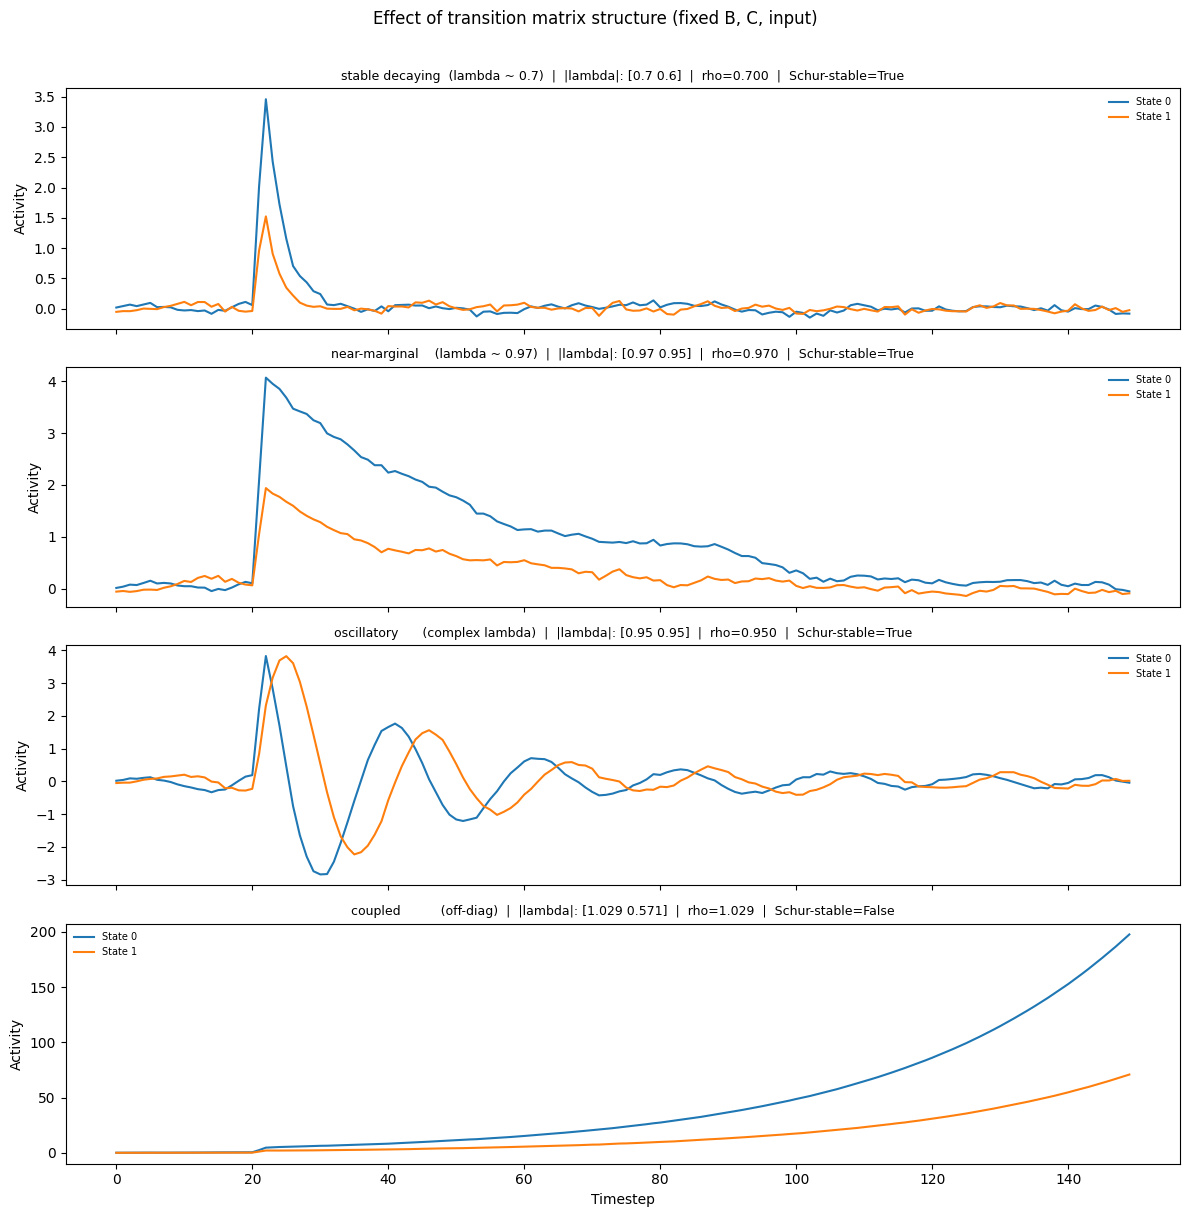

In [6]:
from l4b import InputSignal
from l4b.simulation import Simulator, EigenSpectrum
import matplotlib.pyplot as plt
import numpy as np

T, n_trials = 150, 30
state_dim, input_dim, obs_dim = 2, 1, 2

u = InputSignal.pulse(T, input_dim, onset=20, duration=2, amplitude=2.0)

dynamics_variants = {
    "stable decaying  (lambda ~ 0.7)": np.array([[0.70, 0.00], [0.00, 0.60]]),
    "near-marginal    (lambda ~ 0.97)": np.array([[0.97, 0.00], [0.00, 0.95]]),
    "oscillatory      (complex lambda)": np.array(
        [
            [0.95 * np.cos(0.3), -0.95 * np.sin(0.3)],
            [0.95 * np.sin(0.3), 0.95 * np.cos(0.3)],
        ]
    ),
    "coupled          (off-diag)": np.array([[0.85, 0.50], [0.10, 0.75]]),
}

base_model = {
    "state_dim": state_dim,
    "input_dim": input_dim,
    "obs_dim": obs_dim,
    "B": np.array([[1.0], [0.5]]),
    "C": np.eye(obs_dim),
    "Q": np.eye(state_dim) * 0.03,
    "R": np.eye(obs_dim) * 0.01,
    "seed": 2,
}

fig, axes = plt.subplots(
    len(dynamics_variants), 1, figsize=(12, 3 * len(dynamics_variants)), sharex=True
)

for ax, (label, A) in zip(axes, dynamics_variants.items()):
    sim = Simulator({**base_model, "A": A})
    _, obs = sim.run(np.zeros(state_dim), np.asarray(u), T, trials=n_trials)
    spec = EigenSpectrum(sim).result
    mean_obs = obs.mean(axis=0)
    for k in range(obs_dim):
        ax.plot(mean_obs[:, k], label=f"State {k}")
    ax.set_title(
        f"{label}  |  |lambda|: {np.abs(spec.eigenvalues).round(3)}  "
        f"|  rho={spec.spectral_radius:.3f}  |  Schur-stable={spec.is_schur_stable}",
        fontsize=9,
    )
    ax.set_ylabel("Activity")
    ax.legend(fontsize=7, frameon=False)

axes[-1].set_xlabel("Timestep")
fig.suptitle("Effect of transition matrix structure (fixed B, C, input)", y=1.01)
fig.tight_layout()
plt.show()


## Case study 1: Transient amplification from non-normal dynamics

A matrix $A$ is **non-normal** when $A^T A \neq A A^T$, meaning its eigenvectors are not orthogonal. Even if all eigenvalues satisfy $|\lambda| < 1$ (the system is asymptotically stable), initial conditions or inputs can cause the state to _grow_ transiently before eventually decaying.

**Why?** For $A = V \Lambda V^{-1}$, the discrete response $A^t = V \Lambda^t V^{-1}$. If $V$ is ill-conditioned the norm $\|A^t\|$ can exceed 1 early on even though $|\lambda_i| < 1$ for all eigenvalues. This is quantified by the **numerical range** or by directly plotting $\|A^t x_0\|$ and comparing with a normal matrix with the same spectrum.


non-normal: |lambda|=[0.9 0.8]  rho=0.900  normality defect=8.8459
normal    : |lambda|=[0.9 0.8]  rho=0.900  normality defect=0.0000


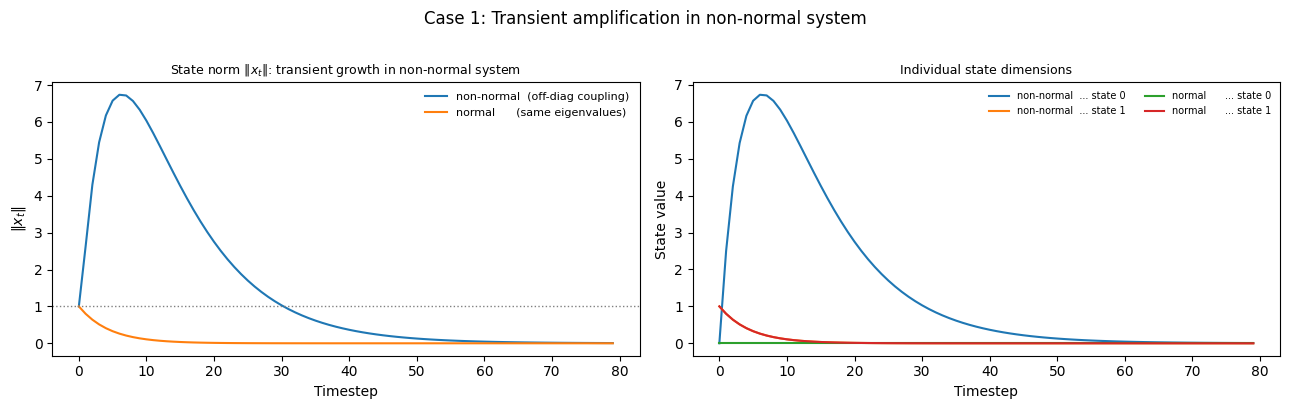

non-normal    peak/initial = 6.738
normal        peak/initial = 1.000


In [7]:
from l4b import InputSignal
from l4b.simulation import Simulator, EigenSpectrum
import matplotlib.pyplot as plt
import numpy as np

T = 80
state_dim, input_dim, obs_dim = 2, 1, 2

# Non-normal A: strong upper-triangular coupling
A_nonnormal = np.array([[0.90, 2.50], [0.00, 0.80]])

# Normal A: same eigenvalues (0.9, 0.8), diagonal
A_normal = np.diag([0.90, 0.80])


def normality_defect(A):
    return np.linalg.norm(A.T @ A - A @ A.T, "fro")


x0 = np.array([0.0, 1.0])  # initial state aligned with second mode
u_zero = InputSignal.zero(T, input_dim)


def make_model(A):
    return {
        "state_dim": state_dim,
        "input_dim": input_dim,
        "obs_dim": obs_dim,
        "A": A,
        "B": np.zeros((state_dim, input_dim)),
        "C": np.eye(obs_dim),
        "Q": np.zeros((state_dim, state_dim)),
        "R": np.zeros((obs_dim, obs_dim)),
        "seed": 0,
    }


# Confirm via EigenSpectrum that both matrices share the same eigenvalues; the
# difference between them is in eigenvector geometry, not the spectrum.
for label, A in [("non-normal", A_nonnormal), ("normal    ", A_normal)]:
    spec = EigenSpectrum(Simulator(make_model(A))).result
    print(
        f"{label}: |lambda|={np.abs(spec.eigenvalues).round(3)}  "
        f"rho={spec.spectral_radius:.3f}  "
        f"normality defect={normality_defect(A):.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, A in [
    ("non-normal  (off-diag coupling)", A_nonnormal),
    ("normal      (same eigenvalues)", A_normal),
]:
    states, _ = Simulator(make_model(A)).run(x0, np.asarray(u_zero), T, trials=1)
    norms = np.linalg.norm(states[0], axis=1)
    axes[0].plot(norms, label=label)
    for k in range(state_dim):
        axes[1].plot(states[0, :, k], label=f"{label[:12]}... state {k}")

axes[0].set_title(
    "State norm $\\|x_t\\|$: transient growth in non-normal system", fontsize=9
)
axes[0].set_xlabel("Timestep")
axes[0].set_ylabel("$\\|x_t\\|$")
axes[0].legend(fontsize=8, frameon=False)
axes[0].axhline(1, color="gray", ls=":", lw=1)

axes[1].set_title("Individual state dimensions", fontsize=9)
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("State value")
axes[1].legend(fontsize=7, frameon=False, ncol=2)

fig.suptitle("Case 1: Transient amplification in non-normal system", y=1.01)
fig.tight_layout()
plt.show()

for label, A in [("non-normal", A_nonnormal), ("normal", A_normal)]:
    states, _ = Simulator(make_model(A)).run(x0, np.asarray(u_zero), T, trials=1)
    norms = np.linalg.norm(states[0], axis=1)
    print(f"{label:12s}  peak/initial = {norms.max() / norms[0]:.3f}")


## Case study 2: Input injection into the observation null-space

The observation matrix $C$ defines which directions in state space are directly visible. Inputs driving the system into $\text{Null}(C)$, the unobservable subspace of $C$, are invisible at the moment of injection but may become observable in the _next_ timestep once $A$ propagates the state into the range of $C$.

This creates an **apparent delay** between stimulus and response in the observations, even though the state is updated instantaneously.


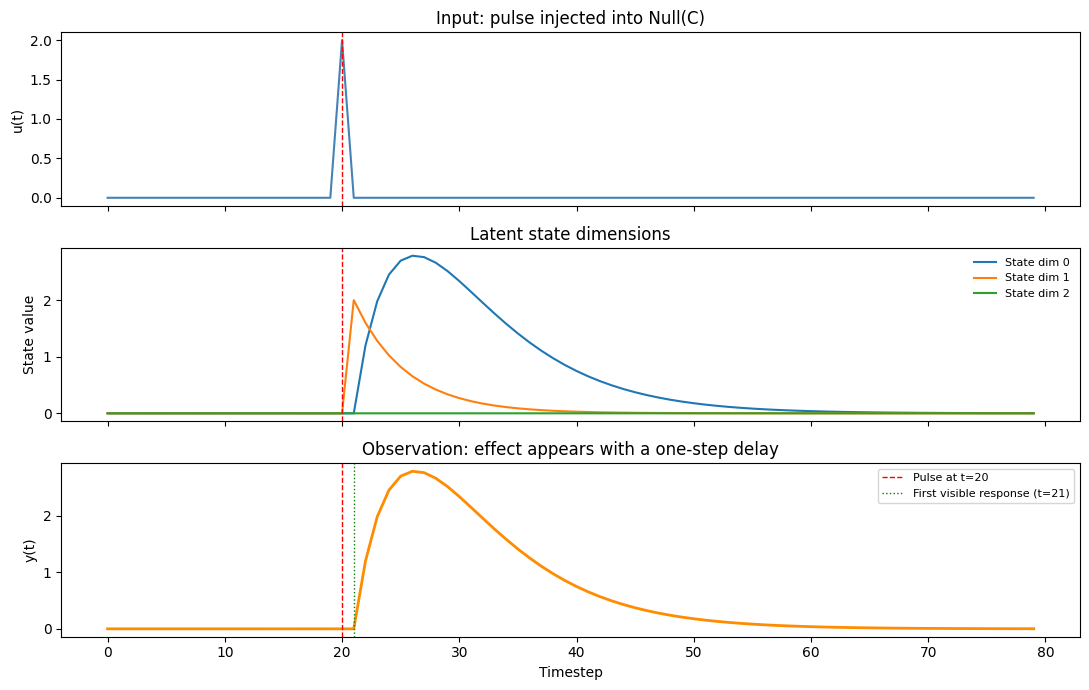

y(t=20  ) = 0.0000   <- input in Null(C), invisible at injection
y(t=21) = 0.0000   <- propagated through A in one step
y(t=22) = 1.2001   <- decaying via eigenvalues of A


In [8]:
from l4b.simulation import Simulator
from l4b import InputSignal
import matplotlib.pyplot as plt
import numpy as np

T, onset = 80, 20
state_dim, input_dim, obs_dim = 3, 1, 1

model_null = {
    "state_dim": state_dim,
    "input_dim": input_dim,
    "obs_dim": obs_dim,
    "A": np.array(
        [
            [0.85, 0.60, 0.00],  # A[0,1] = 0.6: state 1 feeds state 0
            [0.00, 0.80, 0.00],
            [0.00, 0.00, 0.75],
        ]
    ),
    "B": np.array([[0.0], [1.0], [0.0]]),  # drives state 1, which is in Null(C)
    "C": np.array([[1.0, 0.0, 0.0]]),  # only state 0 is observable
    "Q": np.eye(state_dim) * 1e-10,
    "R": np.eye(obs_dim) * 1e-10,
    "seed": 0,
}

u = InputSignal.pulse(T, input_dim, onset=onset, duration=1, amplitude=2.0)
states, obs = Simulator(model_null).run(np.zeros(state_dim), np.asarray(u), T, 1)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(np.asarray(u)[:, 0], color="steelblue")
axes[0].axvline(onset, color="red", ls="--", lw=1)
axes[0].set_ylabel("u(t)")
axes[0].set_title("Input: pulse injected into Null(C)")

for k in range(state_dim):
    axes[1].plot(states[0, :, k], label=f"State dim {k}")
axes[1].axvline(onset, color="red", ls="--", lw=1)
axes[1].set_ylabel("State value")
axes[1].set_title("Latent state dimensions")
axes[1].legend(fontsize=8, frameon=False)

axes[2].plot(obs[0, :, 0], color="darkorange", lw=2)
axes[2].axvline(onset, color="red", ls="--", lw=1, label=f"Pulse at t={onset}")
axes[2].axvline(
    onset + 1,
    color="green",
    ls=":",
    lw=1,
    label=f"First visible response (t={onset + 1})",
)
axes[2].set_ylabel("y(t)")
axes[2].set_xlabel("Timestep")
axes[2].set_title("Observation: effect appears with a one-step delay")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

print(
    f"y(t={onset}  ) = {obs[0, onset, 0]:.4f}   <- input in Null(C), invisible at injection"
)
print(
    f"y(t={onset + 1}) = {obs[0, onset + 1, 0]:.4f}   <- propagated through A in one step"
)
print(
    f"y(t={onset + 2}) = {obs[0, onset + 2, 0]:.4f}   <- decaying via eigenvalues of A"
)

## Case study 3: Ill-conditioned eigenbasis

When the eigenvectors of $A$ are nearly parallel, the eigenbasis matrix $V$ has large condition number $\kappa(V) = \|V\|\|V^{-1}\|$, and the system responds very differently depending on which combination of modes is excited.

**Effects even with real, stable eigenvalues:**

- Apparent oscillations in the deterministic trajectory (mixing between nearly parallel modes).
- Amplified noise variability across trials: a small perturbation in one state dimension projects onto a large combination of modes.
- Sensitivity to initial conditions: nearby starting points diverge transiently before converging.

This is distinct from Case 1 (non-normal $A$): here the eigenbasis itself is degenerate, whereas in Case 1 the eigenvectors are non-orthogonal but not necessarily nearly parallel.


Well-conditioned eigenbasis:  k(V) = 1.00
Ill-conditioned eigenbasis:   k(V) = 40.03
Both have eigenvalues: [0.92 0.85]  (check: [0.92 0.85])


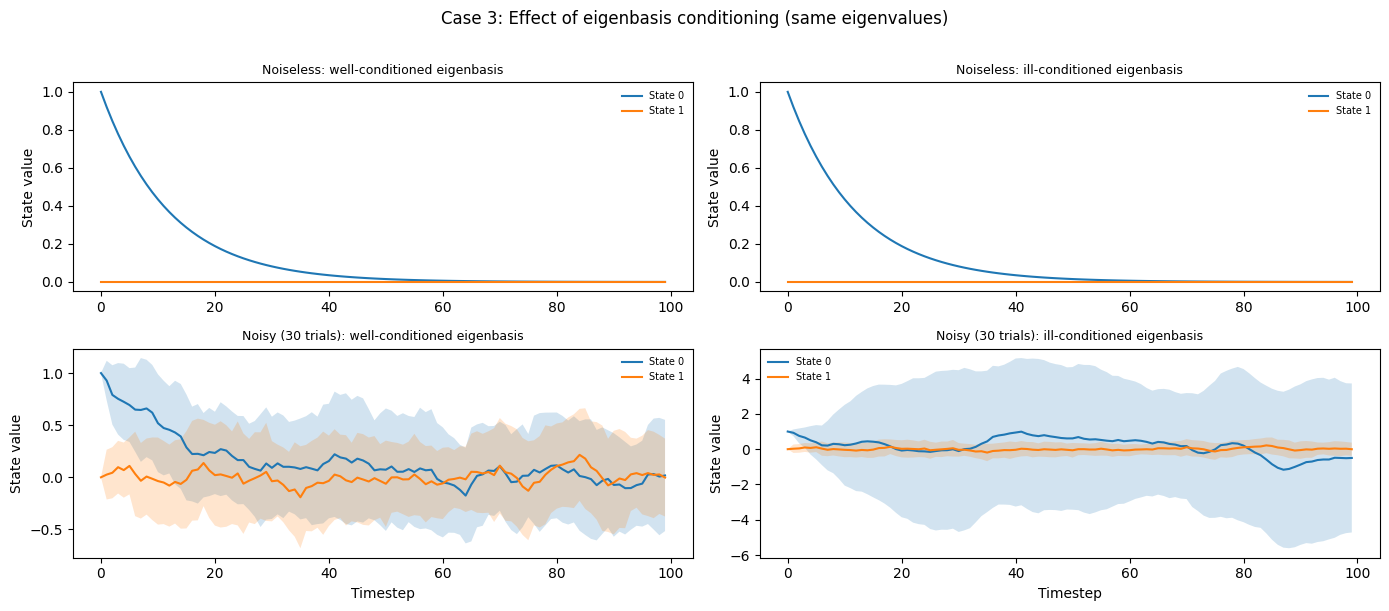

In [9]:
from l4b import InputSignal
from l4b.simulation import Simulator, EigenSpectrum
import matplotlib.pyplot as plt
import numpy as np

T, n_trials = 100, 30
state_dim, input_dim, obs_dim = 2, 1, 2

eps = 0.05
V_good = np.eye(2)
V_bad = np.array([[1.0, 1.0], [0.0, eps]])  # nearly parallel eigenvectors
eigs = np.diag([0.92, 0.85])

A_good = V_good @ eigs @ np.linalg.inv(V_good)
A_bad = V_bad @ eigs @ np.linalg.inv(V_bad)


def make_model(A):
    return {
        "state_dim": state_dim,
        "input_dim": input_dim,
        "obs_dim": obs_dim,
        "A": A,
        "B": np.zeros((state_dim, input_dim)),
        "C": np.eye(obs_dim),
        "Q": np.zeros((state_dim, state_dim)),
        "R": np.zeros((obs_dim, obs_dim)),
        "seed": 3,
    }


sim_good = Simulator(make_model(A_good))
sim_bad = Simulator(make_model(A_bad))

print(f"Well-conditioned eigenbasis:  k(V) = {np.linalg.cond(V_good):.2f}")
print(f"Ill-conditioned eigenbasis:   k(V) = {np.linalg.cond(V_bad):.2f}")
print(
    f"Both have eigenvalues: "
    f"{EigenSpectrum(sim_good).result.eigenvalues.round(4)}  "
    f"(check: {EigenSpectrum(sim_bad).result.eigenvalues.round(4)})"
)

x0 = np.array([1.0, 0.0])
u_zero = np.asarray(InputSignal.zero(T, input_dim))

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for col, (label, sim_nf) in enumerate(
    [
        ("well-conditioned eigenbasis", sim_good),
        ("ill-conditioned eigenbasis", sim_bad),
    ]
):
    states_nf, _ = sim_nf.run(x0, u_zero, T, 1)

    model_noisy = {
        **make_model(sim_nf.A),
        "Q": np.eye(state_dim) * 0.05,
        "R": np.eye(obs_dim) * 0.01,
    }
    states_noisy, _ = Simulator(model_noisy).run(x0, u_zero, T, n_trials)

    for k in range(state_dim):
        axes[0, col].plot(states_nf[0, :, k], label=f"State {k}")
    axes[0, col].set_title(f"Noiseless: {label}", fontsize=9)
    axes[0, col].set_ylabel("State value")
    axes[0, col].legend(fontsize=7, frameon=False)

    mean_ = states_noisy.mean(axis=0)
    std_ = states_noisy.std(axis=0)
    for k in range(state_dim):
        axes[1, col].plot(mean_[:, k], label=f"State {k}")
        axes[1, col].fill_between(
            range(T), mean_[:, k] - std_[:, k], mean_[:, k] + std_[:, k], alpha=0.2
        )
    axes[1, col].set_title(f"Noisy ({n_trials} trials): {label}", fontsize=9)
    axes[1, col].set_ylabel("State value")
    axes[1, col].set_xlabel("Timestep")
    axes[1, col].legend(fontsize=7, frameon=False)

fig.suptitle("Case 3: Effect of eigenbasis conditioning (same eigenvalues)", y=1.01)
fig.tight_layout()
plt.show()


## Controllability and observability analysis

The **controllability Gramian** $W_c(T) = \sum_{t=0}^{T-1} A^t B B^T (A^T)^t$ is full rank if and only if every direction in state space is reachable from zero by some input sequence of length $T$.

The **observability Gramian** $W_o(T) = \sum_{t=0}^{T-1} (A^T)^t C^T C A^t$ is full rank if and only if the initial state is uniquely identifiable from $T$ observations.

The **condition numbers** $\kappa(W_c)$ and $\kappa(W_o)$ quantify _how_ controllable/observable the system is numerically: a large value means some directions are nearly uncontrollable or unobservable even if the formal rank is correct.


In [10]:
from l4b.simulation import Simulator, ControllabilityGramian, ObservabilityGramian
import numpy as np

T = 20  # Gramian horizon

model_full = {
    "state_dim": 3,
    "input_dim": 2,
    "obs_dim": 3,
    "A": np.array([[0.9, 0.1, 0.0], [0.0, 0.8, 0.2], [0.1, 0.0, 0.7]]),
    "B": np.array([[1.0, 0.0], [0.0, 1.0], [0.5, 0.5]]),
    "C": np.eye(3),
    "Q": np.eye(3) * 0.1,
    "R": np.eye(3) * 0.05,
}

# B only drives states 0 and 1; state 2 unreachable
model_unctrl = {
    "state_dim": 3,
    "input_dim": 2,
    "obs_dim": 3,
    "A": np.array([[0.9, 0.1, 0.0], [0.0, 0.8, 0.0], [0.0, 0.0, 0.7]]),
    "B": np.array([[1.0, 0.0], [0.0, 1.0], [0.0, 0.0]]),
    "C": np.eye(3),
    "Q": np.eye(3) * 0.1,
    "R": np.eye(3) * 0.05,
}

# C only sees states 0 and 1; state 2 hidden
model_unobs = {
    "state_dim": 3,
    "input_dim": 2,
    "obs_dim": 2,
    "A": np.array([[0.9, 0.1, 0.0], [0.0, 0.8, 0.0], [0.1, 0.0, 0.7]]),
    "B": np.array([[1.0, 0.0], [0.0, 1.0], [0.5, 0.5]]),
    "C": np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]]),
    "Q": np.eye(3) * 0.1,
    "R": np.eye(2) * 0.05,
}

for name, model in [
    ("Fully controllable + observable", model_full),
    ("Uncontrollable (state 2 isolated)", model_unctrl),
    ("Unobservable  (state 2 hidden)", model_unobs),
]:
    sim = Simulator(model)
    ctrl = ControllabilityGramian(sim, T=T).result
    obs = ObservabilityGramian(sim, T=T).result
    n = model["state_dim"]
    print(f"\n{name}")
    print(
        f"  Controllable: {str(ctrl.is_full_rank):5}  "
        f"rank {ctrl.rank}/{n},  κ = {ctrl.condition:.2e}"
    )
    print(
        f"  Observable:   {str(obs.is_full_rank):5}  "
        f"rank {obs.rank}/{n},  κ = {obs.condition:.2e}"
    )


Fully controllable + observable
  Controllable: True   rank 3/3,  κ = 8.31e+01
  Observable:   True   rank 3/3,  κ = 5.28e+00

Uncontrollable (state 2 isolated)
  Controllable: False  rank 2/3,  κ = inf
  Observable:   True   rank 3/3,  κ = 3.16e+00

Unobservable  (state 2 hidden)
  Controllable: True   rank 3/3,  κ = 1.14e+02
  Observable:   False  rank 2/3,  κ = inf


## Kalman filter: optimal state estimation

Given observations $y_{0:T}$ and known inputs $u_{0:T}$, the Kalman filter computes the **minimum-variance linear unbiased estimate** of the hidden state $x_t$.

The filter alternates between two steps:

1. **Update**: incorporate $y_t$ to form the posterior $\hat{x}_{t|t} = \hat{x}_{t|t-1} + K_t(y_t - C\hat{x}_{t|t-1})$, where $K_t = P_{t|t-1} C^T (C P_{t|t-1} C^T + R)^{-1}$ is the Kalman gain.
2. **Predict**: propagate forward to get the prior $\hat{x}_{t+1|t} = A\hat{x}_{t|t} + Bu_t$, $P_{t+1|t} = A P_{t|t} A^T + Q$.

As $t \to \infty$, $K_t$ converges to a fixed $K_\infty$ obtained by solving the **Discrete Algebraic Riccati Equation (DARE)**, giving the efficient steady-state filter.


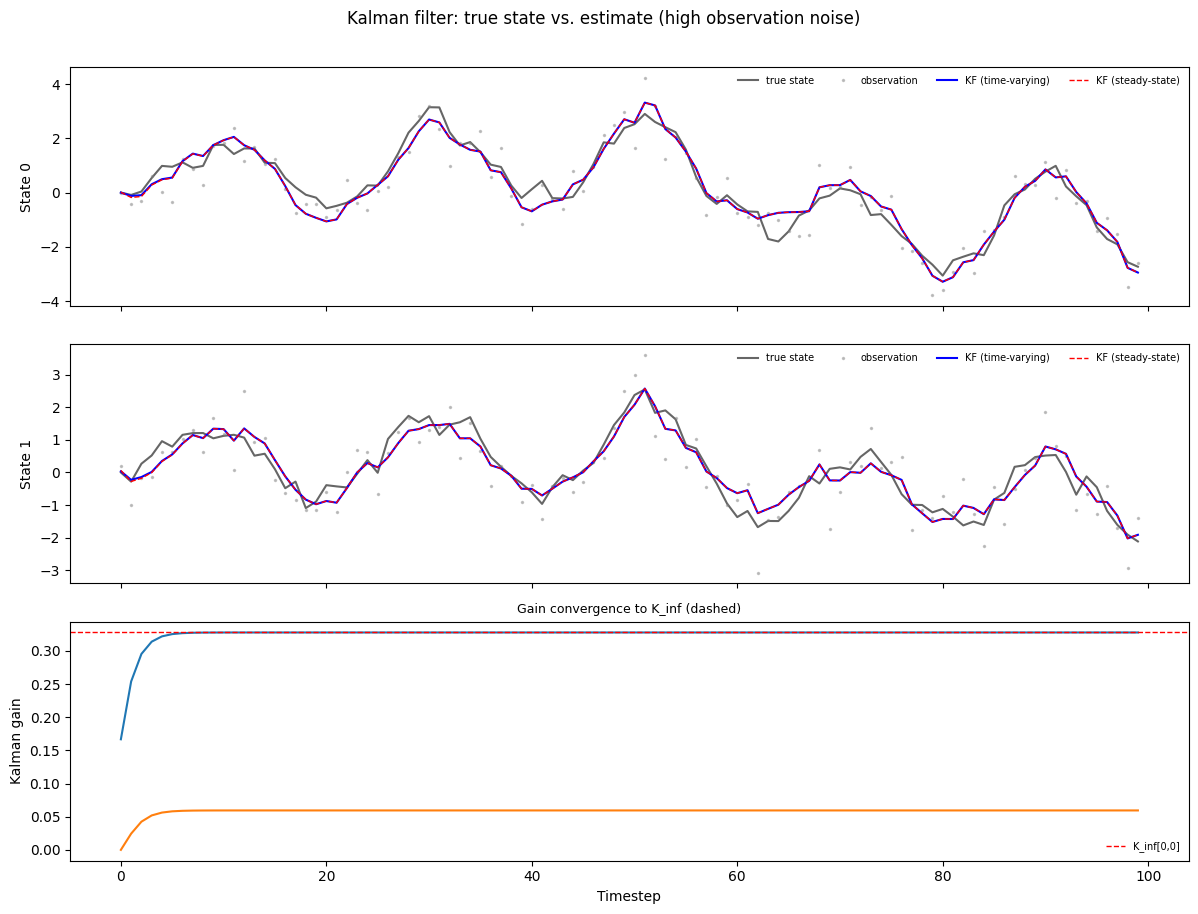

RMSE (raw observations):   0.6112
RMSE (time-varying KF):    0.3523
RMSE (steady-state KF):    0.3532

Steady-state gain K_inf:
[[0.3277 0.0594]
 [0.0594 0.293 ]]


In [11]:
from kalman import KalmanFilter
from l4b import InputSignal
from l4b.simulation import Simulator
import matplotlib.pyplot as plt
import numpy as np

T, state_dim, input_dim, obs_dim = 100, 2, 1, 2

model = {
    "state_dim": state_dim,
    "input_dim": input_dim,
    "obs_dim": obs_dim,
    "A": np.array([[0.9, 0.2], [0.1, 0.85]]),
    "B": np.array([[0.5], [0.3]]),
    "C": np.eye(obs_dim),
    "Q": np.eye(state_dim) * 0.1,
    "R": np.eye(obs_dim) * 0.5,  # high obs noise, estimation is non-trivial
    "seed": 7,
}

u = np.asarray(InputSignal.oscillatory(T, input_dim, frequency=0.05))
true_states, observations = Simulator(model).run(np.zeros(state_dim), u, T, trials=1)

kf = KalmanFilter(model)
result_tv = kf.run(observations[0], u, initial_state=np.zeros(state_dim))
K_inf, P_post = kf.steady_state_gain()
result_ss = kf.run_steady_state(observations[0], u, initial_state=np.zeros(state_dim))

fig, axes = plt.subplots(
    state_dim + 1, 1, figsize=(12, 3 * (state_dim + 1)), sharex=True
)

for k in range(state_dim):
    axes[k].plot(true_states[0, :, k], "k-", lw=1.5, label="true state", alpha=0.6)
    axes[k].plot(
        observations[0, :, k], ".", ms=3, label="observation", alpha=0.4, color="gray"
    )
    axes[k].plot(result_tv.states[:, k], "b-", lw=1.5, label="KF (time-varying)")
    axes[k].plot(result_ss.states[:, k], "r--", lw=1.0, label="KF (steady-state)")
    axes[k].set_ylabel(f"State {k}")
    axes[k].legend(fontsize=7, frameon=False, ncol=4)

gains_tv = result_tv.gains[:, :, 0]
axes[state_dim].plot(gains_tv)
axes[state_dim].axhline(K_inf[0, 0], color="r", ls="--", lw=1, label="K_inf[0,0]")
axes[state_dim].set_ylabel("Kalman gain")
axes[state_dim].set_xlabel("Timestep")
axes[state_dim].set_title("Gain convergence to K_inf (dashed)", fontsize=9)
axes[state_dim].legend(fontsize=7, frameon=False)

fig.suptitle("Kalman filter: true state vs. estimate (high observation noise)", y=1.01)
fig.tight_layout()
plt.show()

rmse_tv = np.sqrt(np.mean((result_tv.states - true_states[0]) ** 2))
rmse_ss = np.sqrt(np.mean((result_ss.states - true_states[0]) ** 2))
rmse_obs = np.sqrt(np.mean((observations[0] - true_states[0]) ** 2))
print(f"RMSE (raw observations):   {rmse_obs:.4f}")
print(f"RMSE (time-varying KF):    {rmse_tv:.4f}")
print(f"RMSE (steady-state KF):    {rmse_ss:.4f}")
print(f"\nSteady-state gain K_inf:\n{K_inf.round(4)}")